In [1]:
import sys
sys.path.append("../../")

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from dextramixer.utils import dist_to_sim
from dextramixer.model import DextraMixer, BEAMT
import muon as mu
import scirpy as ir
import scanpy as sc
import matplotlib.pyplot as plt
import jax.numpy as jnp

/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [173]:
mdat = mu.read("../../data/02_dex_annotated_cd8.h5ad")
mdat

AnnData object with n_obs × n_vars = 53907 × 18471
    obs: 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_v_call', 'IR_VDJ_2_v_call', 'has_ir', 'LTDEMIAQY', 'YTN

In [174]:
mdat2 = ir.io.upgrade_schema(mdat)

In [175]:
gex_obs = ['experiment', 'donor','sample']
airr_obs = ['binding_10x', 'binding_ct', 'clone_id',  'clone_id_size', 
            'clone_size', 'clonotype_sequence']
airr_uns = ["clonotype_sequence_dict", "ir_dist_aa_identity"]

In [176]:
adata_gex = sc.AnnData(mdat.X)
adata_dex = sc.AnnData(mdat.obs[mdat.uns["epitopes"]])
for g in gex_obs:
    adata_gex.obs[g] = mdat.obs[g]
    adata_dex.obs[g] = mdat.obs[g]
adata_dex.var['gene_ids'] = mdat.uns["epitopes"]
adata_gex.var['gene_ids'] = mdat.var.gene_ids

adata_ir = sc.AnnData()
for a in airr_obs:
    adata_ir.obs[a] = mdat.obs[a]

for a in airr_uns:
    adata_ir.uns[a] = mdat.uns[a]
adata_ir.obsm["airr"] = mdat.obsm['airr']

mdata = mu.MuData({"gex":adata_gex, "dex":adata_dex, "airr":adata_ir})
mdata

MuData object with n_obs × n_vars = 107814 × 18492
  3 modalities
    gex:	53907 x 18471
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids'
    dex:	53907 x 21
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids'
    airr:	53907 x 0
      obs:	'binding_10x', 'binding_ct', 'clone_id', 'clone_id_size', 'clone_size', 'clonotype_sequence'
      uns:	'clonotype_sequence_dict', 'ir_dist_aa_identity'
      obsm:	'airr'

# Filtering

In [177]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

In [178]:
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: x != "multichain")
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ"]))


In [179]:
mdata.mod["airr"].obs["clone_id_felix"] = mdata.mod["airr"].obs["clone_id"]

In [180]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13715/13715 [00:08<00:00, 1689.20it/s]


In [181]:
ir.tl.clonotype_network(mdata, min_cells=2)

In [182]:
# remove cells without clonotype information
mu.pp.filter_obs(mdata, "airr:clone_id", lambda x:  x != 'nan')

In [ ]:
ir.pp.ir_dist(
    mdata,
    metric="alignment",
    sequence="aa",
    cutoff=255,
)

In [47]:
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any", chunksize=500)

  0%|                                                                                                                                            | 0/14091 [06:20<?, ?it/s]

KeyboardInterrupt



# Example LTDEMIAQY

In [3]:
experiment = "third_experiment"

In [196]:


mdat_LTD = mdata[:,"LTDEMIAQY"].copy()
mu.pp.filter_obs(mdat_LTD, "dex:experiment", lambda x: np.isin(x, [experiment]))

ir.pp.ir_dist(
    mdat_LTD,
    metric="alignment",
    sequence="aa",
    cutoff=255,
)

ir.tl.define_clonotype_clusters(mdat_LTD, sequence="aa", metric="alignment", receptor_arms="all", dual_ir="primary_only")
dist = (mdat_LTD.mod["airr"].uns["cc_aa_alignment"]["distances"].todense() - 1).astype("float64")

/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 528/528 [38:36<00:00,  4.39s/it]


In [204]:
mdat_LTD.mod["airr"].uns["cc_aa_alignment"]
cc_clone_id = {"cell_id": [], "clone_id":[]}
for c_id, umi_list in mdat_LTD.mod["airr"].uns["cc_aa_alignment"]["cell_indices"].items():
    for umi in umi_list:
        cc_clone_id["clone_id"].append(c_id)
        cc_clone_id["cell_id"].append(umi)
df_cc_clone_id = pd.Series(data=cc_clone_id["clone_id"], index=cc_clone_id["cell_id"])
mdat_LTD.mod["airr"].obs["cc_aa_clone_id"] = df_cc_clone_id

In [200]:
from dextramixer.utils import dist_to_sim
mdat_LTD.mod['airr'].uns["ir_alignment_cov"] = np.asarray(dist_to_sim(dist))

In [205]:
mdat_LTD.write("mdat_LTD_second_experiment.h5mu")

# Inference

In [4]:
mdat_LTD = mu.read("mdat_LTD_{}.h5mu".format(experiment))
mdat_LTD

/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/utils.py:334: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 11749 × 1
  3 modalities
    gex:	0 x 0
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids'
    dex:	11749 x 1
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids'
    airr:	11749 x 0
      obs:	'binding_10x', 'binding_ct', 'clone_id', 'clone_id_size', 'clone_size', 'clonotype_sequence', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id_felix', 'cc_aa_alignment', 'cc_aa_alignment_size', 'cc_aa_clone_id', 'p_H_Cov', 'assignment_H_Cov'
      uns:	'H_cov_summary', 'cc_aa_alignment', 'chain_indices', 'clone_id', 'clonotype_network', 'clonotype_sequence_dict', 'ir_alignment_cov', 'ir_dist_aa_alignment', 'ir_dist_aa_identity', 'ir_dist_nt_identity'
      obsm:	'X_clonotype_network', 'airr', 'chain_indices'

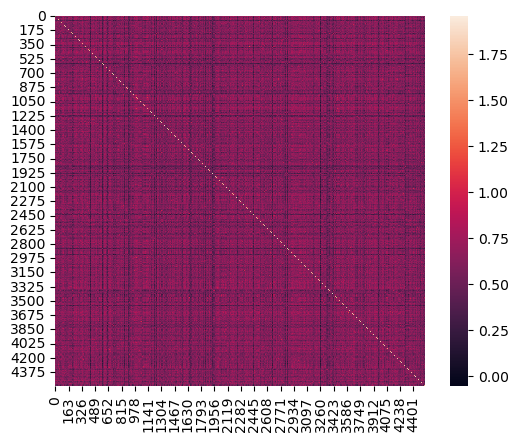

In [5]:
sns.heatmap(mdat_LTD.mod['airr'].uns["ir_alignment_cov"],square=True);

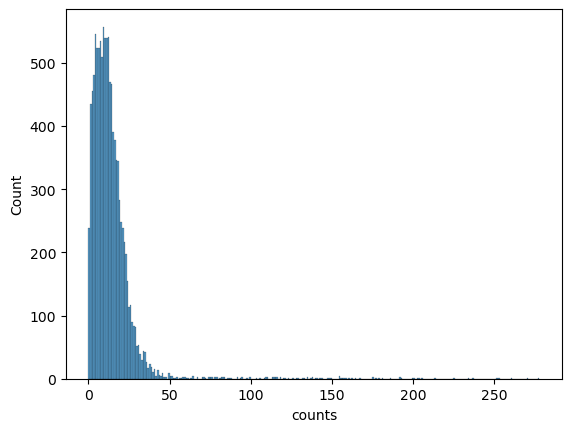

In [6]:
df = pd.DataFrame.from_dict({"counts":mdat_LTD.mod["dex"].X[:,0]})
sns.histplot(data=df, x="counts", fill=True, log_scale=False);

In [14]:
import numpyro

numpyro.set_host_device_count(6)

mixer = DextraMixer(model_type="mixturemodel", mode="H")
#ir_cov_key="ir_alignment_cov"
mixer.preprocess_model_data(mdat_LTD, pmhc_key="LTDEMIAQY", gex_key="dex", ir_clone_key="cc_aa_clone_id")
trace = mixer.fit_svi(numpyro.infer.autoguide.AutoNormal, rng_key=42)
mixer.summary()

/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/jax/_src/numpy/lax_numpy.py:3198: RuntimeWarning: invalid value encountered in cast
  out = np.asarray(object, dtype=dtype)
100%|████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 327.05it/s, init loss: 88293.3516, avg. loss [951-1000]: 41246.5859]
arviz - WARNING - Shape validation failed: input_shape: (1, 500), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,2.154,0.047,2.058,2.240,0.002,0.002,413.0,279.0,NaN
mu_q,1.291,0.599,0.127,2.381,0.025,0.018,576.0,453.0,NaN
q[0],5.008,0.074,4.869,5.144,0.003,0.002,570.0,511.0,NaN
q[1],17.385,0.158,17.108,17.680,0.007,0.005,505.0,473.0,NaN
sigma_q,1.615,1.184,0.325,3.590,0.060,0.042,406.0,371.0,NaN
...,...,...,...,...,...,...,...,...,...
"w[4540, 1]",0.397,0.266,0.005,0.854,0.013,0.009,455.0,347.0,NaN
"w[4541, 0]",0.656,0.269,0.165,0.996,0.012,0.009,490.0,421.0,NaN
"w[4541, 1]",0.344,0.269,0.004,0.835,0.012,0.009,490.0,421.0,NaN
"w[4542, 0]",0.608,0.260,0.169,0.990,0.012,0.009,467.0,501.0,NaN


In [15]:
p, assignment = mixer.predict_posterior_class(target_fdr=0.05)
np.sum(assignment), np.min(p), np.max(p), np.median(p)

(Array(5791, dtype=int32),
 Array(0.00159759, dtype=float32),
 Array(1., dtype=float32),
 0.71583235)

In [16]:
mdat_LTD.mod["airr"].obs["p_H_Cov"] = p
mdat_LTD.mod["airr"].obs["assignment_H_Cov"] = assignment
mdat_LTD.mod["airr"].uns["H_cov_summary"] = mixer.summary()
#mdat_LTD.write("mdat_LTD_{}.h5mu".format(experiment))

arviz - WARNING - Shape validation failed: input_shape: (1, 500), minimum_shape: (chains=2, draws=4)


<Axes: xlabel='counts', ylabel='Count'>

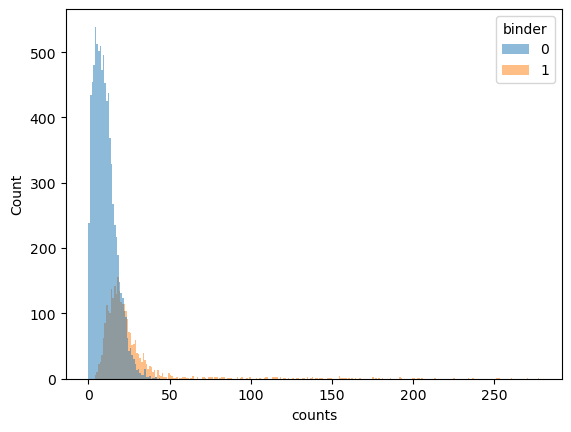

In [12]:
df = pd.DataFrame.from_dict({"counts":mdat_LTD.mod["dex"].X[:,0], "binder":assignment})
sns.histplot(data=df,x="counts", hue="binder", fill=True,log_scale=False, common_norm=False, alpha=.5, linewidth=0)

<Axes: xlabel='counts', ylabel='Count'>

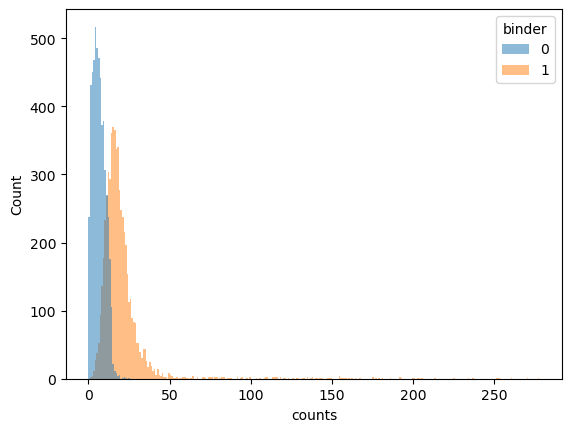

In [17]:
df = pd.DataFrame.from_dict({"counts":mdat_LTD.mod["dex"].X[:,0], "binder":assignment})
sns.histplot(data=df,x="counts", hue="binder", fill=True,log_scale=False, common_norm=False, alpha=.5, linewidth=0)

# Experimental Verification

In [18]:
exp_results = pd.read_excel("Determined TCR avidity_Katha.xlsx", header=0)
exp_results = exp_results[exp_results.donor != "A29"]
unreactive_clones = ['10623.0', '4350.0', '2123.0', '1690.0', '9973.0']

In [19]:
mdat_LTD.mod["airr"].obs["clone_id_felix"]

cell_id
AAACCTGAGATTACCC-1-0-1    12291.0
AAACCTGAGGTCGGAT-1-0-1    12294.0
AAACCTGCAATAGCGG-1-0-1    12296.0
AAACCTGCATTCCTCG-1-0-1    12300.0
AAACCTGGTACCCAAT-1-0-1    12301.0
                           ...   
TTTGCGCTCTCTGAGA-1-2-1    20269.0
TTTGGTTGTTCGGGCT-1-2-1     9041.0
TTTGGTTTCCACGACG-1-2-1      926.0
TTTGTCACAGCTGCAC-1-2-1      926.0
TTTGTCATCCTATGTT-1-2-1     1303.0
Name: clone_id_felix, Length: 11749, dtype: category
Categories (4442, object): ['2.0', '9.0', '12.0', '16.0', ..., '20266.0', '20267.0', '20269.0', '20272.0']

In [20]:
exp_results[exp_results.Clone.isin(mdat_LTD.mod["airr"].obs["clone_id_felix"].astype("float"))]

,Clone,IFNg EC50,mTRBC EC50,donor
1,772.0,1.347000e-07,2.227000e-07,A4
2,99.0,1.562000e-07,2.787000e-06,A4
4,718.0,1.723000e-07,2.601000e-06,A4
8,11195.0,3.633000e-07,1.246000e-06,A4
11,5918.0,4.403000e-07,8.157000e-07,A4
13,7100.0,4.854000e-07,2.326000e-06,A4
15,832.0,5.102000e-07,1.061000e-06,A4
18,297.0,1.532000e-06,1.274000e-05,A4
19,11751.0,1.512000e-07,3.054000e-06,A8
20,7287.0,2.045000e-07,1.352000e-06,A8


In [21]:
df_airr = mdat_LTD.mod["airr"].obs[["clone_id_felix", "p_H_Cov", "assignment_H_Cov"]]
df_airr["LTD"] = mdat_LTD.mod["dex"].X[:,0]
df_airr["clone_id_felix"] = df_airr["clone_id_felix"].astype("float") 
df = pd.merge(exp_results, df_airr, how="inner", left_on="Clone", right_on="clone_id_felix")
df

/var/folders/lv/3y_r3tmn6x35q5ccp_z_ttmc0000gn/T/ipykernel_79538/1404460650.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_airr["LTD"] = mdat_LTD.mod["dex"].X[:,0]
/var/folders/lv/3y_r3tmn6x35q5ccp_z_ttmc0000gn/T/ipykernel_79538/1404460650.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_airr["clone_id_felix"] = df_airr["clone_id_felix"].astype("float")


,Clone,IFNg EC50,mTRBC EC50,donor,clone_id_felix,p_H_Cov,assignment_H_Cov,LTD
0,772.0,1.347000e-07,2.227000e-07,A4,772.0,1.00000,1,98.0
1,99.0,1.562000e-07,2.787000e-06,A4,99.0,1.00000,1,72.0
2,99.0,1.562000e-07,2.787000e-06,A4,99.0,1.00000,1,135.0
3,99.0,1.562000e-07,2.787000e-06,A4,99.0,1.00000,1,76.0
4,718.0,1.723000e-07,2.601000e-06,A4,718.0,1.00000,1,204.0
...,...,...,...,...,...,...,...,...
93,1701.0,1.807000e-07,2.070000e-06,HIM,1701.0,1.00000,1,157.0
94,2997.0,2.962000e-07,1.610000e-06,HIM,2997.0,1.00000,1,111.0
95,475.0,2.986000e-07,2.470000e-06,HIM,475.0,0.99959,1,42.0
96,5546.0,4.082000e-07,2.860000e-06,HIM,5546.0,1.00000,1,71.0


<Axes: xlabel='LTD', ylabel='mTRBC EC50'>

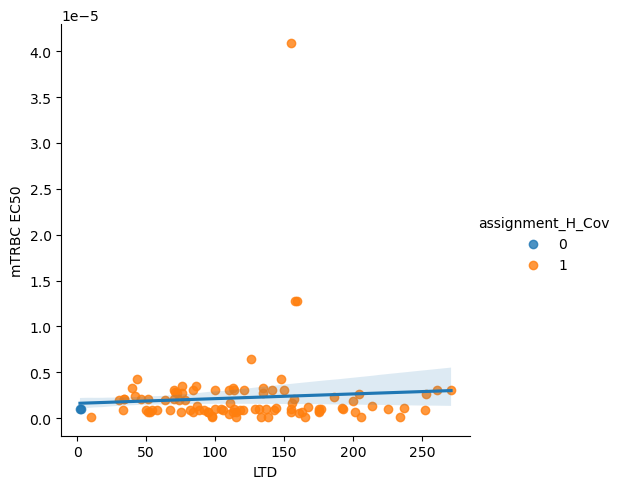

In [24]:
ax = sns.lmplot(data=df, x="LTD", y="mTRBC EC50",hue="assignment_H_Cov", fit_reg=False, truncate=False);
sns.regplot(x="LTD", y="mTRBC EC50", data=df, scatter=False, logistic=False, ax=ax.axes[0, 0])

<Axes: xlabel='LTD', ylabel='IFNg EC50'>

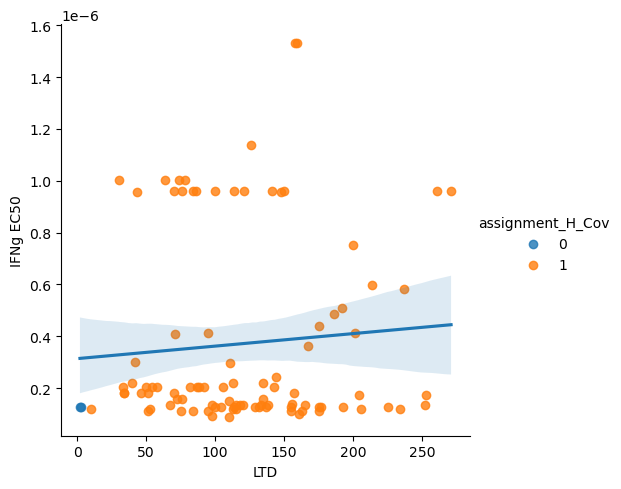

In [25]:
ax = sns.lmplot(data=df, x="LTD", y="IFNg EC50",hue="assignment_H_Cov", fit_reg=False, truncate=False);
sns.regplot(x="LTD", y="IFNg EC50", data=df, scatter=False, logistic=False, ax=ax.axes[0, 0])

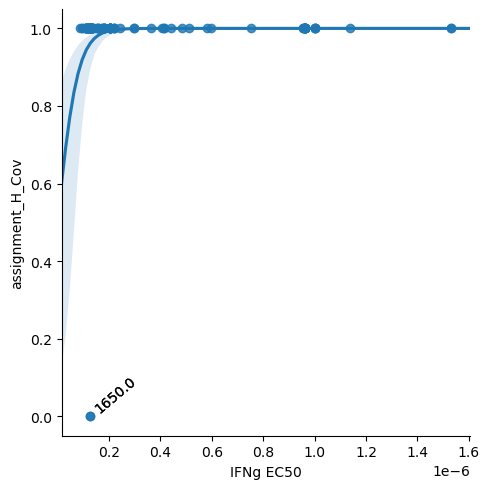

In [26]:
ax = sns.lmplot(data=df, x="IFNg EC50", y="assignment_H_Cov",  logistic=True, truncate=False);
p1 = plt.gca()
for  i,row in df.iterrows():
     if row.assignment_H_Cov == 0:
         p1.text(row["IFNg EC50"]+1e-8, row.assignment_H_Cov+0.01, row.Clone, horizontalalignment='left', rotation=40)

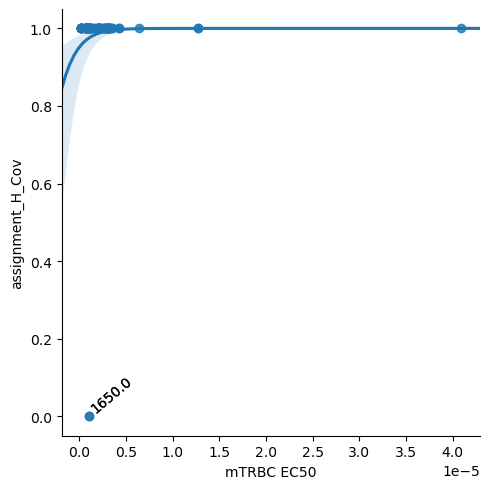

In [27]:
ax = sns.lmplot(data=df, x="mTRBC EC50", y="assignment_H_Cov",  logistic=True, truncate=False);
p1 = plt.gca()
for  i,row in df.iterrows():
     if row.assignment_H_Cov == 0:
         p1.text(row["mTRBC EC50"]+1e-8, row.assignment_H_Cov+0.01, row.Clone, horizontalalignment='left', rotation=40)

/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


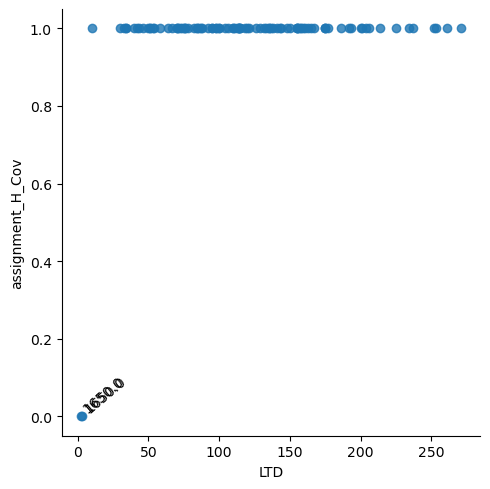

In [28]:
import matplotlib.pyplot as plt

ax = sns.lmplot(data=df, x="LTD", y="assignment_H_Cov",  logistic=True, truncate=False);
p1 = plt.gca()
for  i,row in df.iterrows():
     if row.assignment_H_Cov == 0:
         p1.text(row["LTD"]+1e-8, row.assignment_H_Cov+0.01, row.Clone, horizontalalignment='left', rotation=40)

<Axes: xlabel='LTD', ylabel='p_H_Cov'>

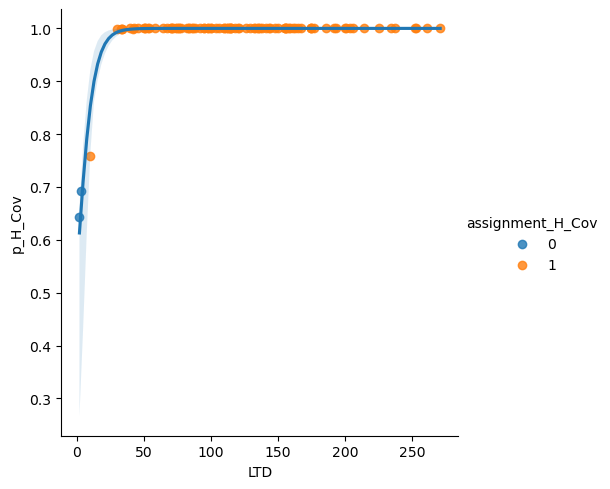

In [29]:
ax = sns.lmplot(data=df, x="LTD", y="p_H_Cov",hue="assignment_H_Cov", fit_reg=False, truncate=False);
sns.regplot(x="LTD", y="p_H_Cov", data=df, scatter=False, logistic=True, ax=ax.axes[0, 0])

In [31]:
print("Total", len(df), "TP",np.sum(df.assignment_H_Cov),"FP", np.sum(df.assignment_H_Cov != 1), "Recall", np.sum(df.assignment_H_Cov)/len(df))

Total 98 TP 96 FP 2 Recall 0.9795918367346939


In [ ]:
df_unreactive = mdat_LTD.mod["airr"].obs[mdat_LTD.mod["airr"].obs["clone_id_felix"].isin(unreactive_clones)]
df_unreactive

In [ ]:
mdat_LTD.mod["dex"][df_unreactive.index].X

In [98]:
mdat_LTD_binder = mdat_LTD[mdat_LTD.mod["airr"].obs["assignment_H_Cov"] == 1]
mdat_LTD_binder

with ir.get.airr_context(mdat_LTD_binder, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    binder = (
         mdat_LTD_binder.obs
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
binder

,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells
0,CAAAGSARQLTF,CASSLEYFTYEQYF,nan,nan,TRA+TRB,1
1,CAAARVSTSGTYKYIF,CASSFMSTTEAFF,nan,nan,TRA+TRB,1
2,CAADQAGTALIF,CASALGYDEQYF,nan,nan,TRA+TRB,1
3,CAAGSSGGSYIPTF,CASSLEGHRGLYNEQFF,nan,nan,TRA+TRB,1
4,CAAILLTGGGNKLTF,CSARDLSGPAGETQYF,CAIPAFSGGYNKLIF,CASSGGLHNEQFF,TRA+TRB,1
...,...,...,...,...,...,...
221,CVSNTGKLIF,CASSDPQETQYF,CAMRSNYQLIW,nan,TRA+TRB,1
222,CVVNLRDNYGQNFVF,CASSLGSMNTEAFF,nan,nan,TRA+TRB,7
223,CVVNNARLMF,CASEEADRVFTGELFF,nan,nan,TRA+TRB,4
224,CVVSDRDNARLMF,CASSLVSGPPAGELFF,CAVRDPDNNNDMRF,nan,TRA+TRB,1


/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/scirpy/tl/_spectratype.py:75: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  obs["lengths"] = airr_df.applymap(len).apply(combine_fun, axis=1)


<Axes: title={'center': 'Spectratype of junction_aa by airr:assignment_H_Cov'}, xlabel='junction_aa length', ylabel='Number of cells'>

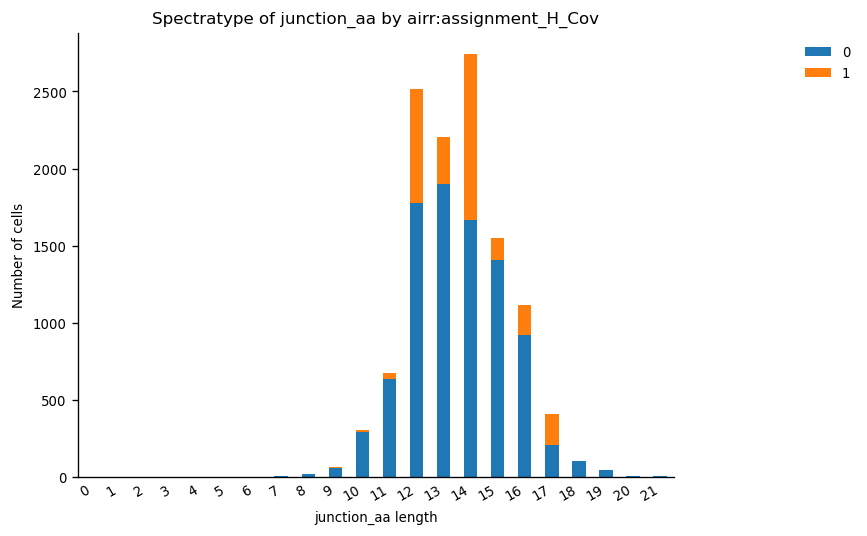

In [114]:
ir.pl.spectratype(mdat_LTD, color="airr:assignment_H_Cov", viztype="bar", fig_kws={"dpi": 120})

In [112]:
mdat_LTD_binder

MuData object with n_obs × n_vars = 2719 × 1
  3 modalities
    gex:	0 x 0
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids'
    dex:	2719 x 1
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids'
    airr:	2719 x 0
      obs:	'binding_10x', 'binding_ct', 'clone_id', 'clone_id_size', 'clone_size', 'clonotype_sequence', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id_felix', 'cc_aa_alignment', 'cc_aa_alignment_size', 'cc_aa_clone_id', 'p_H_Cov', 'assignment_H_Cov'
      uns:	'cc_aa_alignment', 'chain_indices', 'clone_id', 'clonotype_network', 'clonotype_sequence_dict', 'ir_alignment_cov', 'ir_dist_aa_alignment', 'ir_dist_aa_identity', 'ir_dist_nt_identity', 'H_cov_summary'
      obsm:	'X_clonotype_network', 'airr', 'chain_indices'

In [117]:
from palmotif import compute_motif, svg_logo

motif = compute_motif(np.unique(binder[binder["VDJ_1_junction_aa"].str.len() == 14]["VDJ_1_junction_aa"]).tolist())
_ = svg_logo(
    motif, "./logo_second_experiment_binder_H_Cov.svg", color_scheme="taylor"
)

In [124]:
mdat_LTD_nonbinder = mdat_LTD[mdat_LTD.mod["airr"].obs["assignment_H_Cov"] == 0]
mdat_LTD_nonbinder

with ir.get.airr_context(mdat_LTD_nonbinder, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    nonbinder = (
         mdat_LTD_nonbinder.obs
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
nonbinder

,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells
0,CAAAATDSWGKLQF,CASSLSGTRNEQFF,nan,nan,TRA+TRB,1
1,CAAALGNNNDMRF,CASSSYPEDGFNYGYTF,nan,nan,TRA+TRB,1
2,CAAAMNRDDKIIF,CASSFPTSGTSYEQYF,nan,nan,TRA+TRB,1
3,CAAAPFRSEKLVF,CASSQEKSRTGDYEQYF,nan,nan,TRA+TRB,1
4,CAAATNNAGNMLTF,CASSQAGGGSPLHF,nan,nan,TRA+TRB,1
...,...,...,...,...,...,...
4530,CVVWGRDDKIIF,CASSQTAGSHSYEQYF,nan,nan,TRA+TRB,1
4531,CVVYIGTNAGKSTF,CASSSPWTGGLNEGPLHF,nan,nan,TRA+TRB,1
4532,CVVYTDKLIF,CSPTGPRLNYGYTF,nan,nan,TRA+TRB,1
4533,CVYQGGKLIF,CASSSWPENTEAFF,nan,nan,TRA+TRB,1


In [125]:
from palmotif import compute_motif, svg_logo

motif = compute_motif(np.unique(nonbinder[nonbinder["VDJ_1_junction_aa"].str.len() == 14]["VDJ_1_junction_aa"]).tolist())
_ = svg_logo(
    motif, "./logo_second_experiment_nonbinder_H_Cov.svg", color_scheme="taylor"
)

In [148]:
aa_alphabet = [aa for aa in 'ARNDCQEGHILKMFPSTWYVBZX-']
search_patter= []
for j in range(motif.shape[1]):
    idx = np.where(motif[j] >0.05)[0]
    print(idx)
    a = aa_alphabet[idx[0]] if len(idx) == 1 else "[{}]".format("".join(aa_alphabet[i] for i in idx))
    search_patter.append(a)
print("".join(search_patter))
        

[4]
[ 0 15]
[ 0  9 15 16 17 19]
[ 1 11 15 16]
[ 5  7 10 14 15]
[ 0  1  3  7 10 14 15 16]
[ 0  1  3  5  7 15 16]
[ 0  1  6  7 15 16 19]
[ 0  2  7 15 16 18]
[ 2  3  5  6  7 15 16 18]
[ 6  7 11 14 16]
[ 0  5  9 10 18]
[ 8 13 16 18]
[13]
C[AS][AISTWV][RKST][QGLPS][ARDGLPST][ARDQGST][AREGSTV][ANGSTY][NDQEGSTY][EGKPT][AQILY][HFTY]F


In [155]:
with ir.get.airr_context(mdat_LTD, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    clone_475 = (mdat_LTD.obs.loc[lambda x: x["airr:clone_id_felix"] == "475.0"]
    .astype(str)
    .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
clone_475

,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells
0,CAVSGPTSGTYKYIF,CASSLWDGGNQPQHF,nan,nan,TRA+TRB,1
